### Imports + Loading Data

In [1]:
# Modules:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline, Pipeline

import joblib
import pickle
import os

#Data:
X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None
# with open("Data/Transformed/split.pkl", "rb") as file:
with open("Data/Transformed_OutlierAdjusted/split.pkl", "rb") as file:
    data_dict = pickle.load(file)
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_val = data_dict["X_val"]
    y_val = data_dict["y_val"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]
Xcolumns = X_train.columns
ycolumns = y_train.columns


### Select Model

#### First Example - Pure Linear Regression
Here linear regression with degree 2 polynomial yields best performance on validation set

In [3]:
# Parameters
degree = 3

# Generate Polynomial Features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

# Fit Model
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_train_pred = model.predict(X_train_poly)

# Make Validation Prediction
y_val_pred = model.predict(X_val_poly)

# Calculate Loss
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }
    
MAE = mean_absolute_error(y_val_pred, y_val)
MSE = mean_squared_error(y_val_pred, y_val)
RMSE = mean_squared_error(y_val_pred, y_val, squared = False)
print("Train:     ", evaluate(y_train, y_train_pred))
print("Validation:", evaluate(y_val, y_val_pred))

# With outliers
# Degree - Score            - Time
# 1 - 0.6921081246450294    - 0s
# 2 - 0.6448701402635438    - 0.1s
# 3 - 130.98022425616296    - 1.1s
# 4 - 2.913879351182915e+18 - 50s

# Without outliers
# Degree - Score            - Time
# 1 - 0.11636017040955975   - s
# 2 - 0.07103959423496792   - s
# 3 - 13.28382555433066     - 1s
# 4 - 6315402501.905555     - 49s

Train:      {'MAE': 0.03763928576581608, 'MSE': 0.0062007773353946255, 'RMSE': 0.07740520785786847}
Validation: {'MAE': 0.40944808252770304, 'MSE': 13.28382555433066, 'RMSE': 3.5080275570656756}


#### kFoldCV on LinearRegression

In [39]:
# Parameters
degree = 3
cv = 10

# Create model pipeline
pipeline = Pipeline([
    ("transformer", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", LinearRegression())
])

# Fit model
n_cpu = os.cpu_count()-1
kf=KFold(n_splits=cv, shuffle = True, random_state=42)
cv_results = cross_validate(estimator = pipeline,
                            X=pd.concat([X_train, X_val]),
                            y=pd.concat([y_train, y_val]),
                            cv=kf,
                            scoring = ["neg_mean_absolute_error", "neg_mean_squared_error"],
                            n_jobs = n_cpu)

# cv_results
print("Validation:  MAE =", -np.mean(cv_results["test_neg_mean_squared_error"]))

# With outliers
# Degree - Score          - Time
# 1 - 0.7959225812505373  - 0.0s
# 2 - 0.7898725364769725  - 0.2s
# 3 - 1522.202266949534   - 6.4s

# Without outliers
# Degree - Score          - Time
# 1 - 0.12059568662072788  - 0.0s
# 2 - 0.06503967545104587 - 0.2s
# 3 - 35.574250227250175  - 6.4s


Validation:  MAE = 35.574250227250175


#### kFoldCV on Ridge

In [83]:
# Parameters
degree = 4
alpha = 0.0001
cv = 10

# Create model pipeline
pipeline = Pipeline([
    ("transformer", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", Ridge(alpha=alpha, tol=0.0001))
])

# Fit model
n_cpu = os.cpu_count()-2
kf=KFold(n_splits=cv, shuffle = True, random_state=42)
cv_results = cross_validate(estimator = pipeline,
                            X=pd.concat([X_train, X_val]),
                            y=pd.concat([y_train, y_val]),
                            cv=kf,
                            scoring = ["neg_mean_absolute_error", "neg_mean_squared_error"],
                            n_jobs = n_cpu)

# cv_results
print("Validation:  MAE =", -np.mean(cv_results["test_neg_mean_squared_error"]))

# With outliers
# Degree - alpha - Score          - Time
# 1 -    0.05  - 0.7958721511986733  - 0.0s
# 2 -    0.006 - 0.7383346163995406  - 0.1s
# 3 -    0.020 - 0.7254865188079445  - 0.8s
# 4 -    0.068 - 0.7219869526402052  - 11.8s

# Without outliers
# Degree - alpha - Score          - Time
# 1 -  0.05    - 0.12055468258509698  - 0s
# 2 -  0.0009  - 0.05257385905913283  - 0s
# 3 -  0.0010  - 0.03259156754934951  - 1s
# 4 -  0.0001  - 0.029900006318499872  - 11s

#### kFold on Lasso

In [9]:
# Parameters
degree = 2
alpha = 0.001
cv = 10

# Create model pipeline
pipeline = Pipeline([
    ("transformer", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", Lasso(alpha=alpha, tol=0.0001))
])

# Fit model
n_cpu = os.cpu_count()-2
kf=KFold(n_splits=cv, shuffle = True, random_state=42)
cv_results = cross_validate(estimator = pipeline,
                            X=pd.concat([X_train, X_val]),
                            y=pd.concat([y_train, y_val]),
                            cv=kf,
                            scoring = ["neg_mean_absolute_error", "neg_mean_squared_error"],
                            n_jobs = n_cpu)

# cv_results
print("Validation:  MAE =", -np.mean(cv_results["test_neg_mean_squared_error"]))

# With outliers
# Degree - alpha - Score          - Time
# 1 - 0.0007  - 0.7992786170395468  - 0.0s
# 2 - 0.001   - 0.7759006441277382  - 5.9s
# 3 - 0.001   - 0.7715416440248016  - 52.3s

# Without outliers
# Degree - alpha - Score          - Time
# 1 - 0.0001  - 0.18598858499275772 - s
# 2 - 0.001   - 0.16949582558659487 - s
#  No gain over ridge

/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.150e+01, tolerance: 3.130e-01
  model = cd_fast.enet_coordinate_descent(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.716e+00, tolerance: 3.128e-01
  model = cd_fast.enet_coordinate_descent(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

Validation:  MAE = 0.16949582558659487


/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.528e-02, tolerance: 6.882e-02
  model = cd_fast.enet_coordinate_descent(


#### GridSearchCV on ElasticNet Model

In [27]:
# Hyperparameters
degree = 2

# Round 1
alphas = np.round(np.logspace(-3, 0, 10, dtype = float, endpoint=True), 5)   #regularization for combined penalty term
l1_ratios = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]

# Round 2
alphas = np.round(np.logspace(-4, -2, 10, dtype = float, endpoint=True), 6)   #regularization for combined penalty term
l1_ratios = [0.99, 0.999, 0.9999, 0.99999]

cv = 10

# Create model pipeline
pipeline = Pipeline([
    ("transformer", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", ElasticNet(tol=0.001))
])

# Fit model
n_cpu = os.cpu_count()-2
param_grid = {
    "regressor__alpha": alphas, 
    "regressor__l1_ratio": l1_ratios
              }
kf=KFold(n_splits=cv, shuffle = True, random_state=42)
model_grid_cv = GridSearchCV(estimator = pipeline,
                             param_grid = param_grid,
                             scoring = "neg_mean_squared_error",
                             cv = kf,
                             verbose = 0,
                             n_jobs = n_cpu,
                             verbose = 1)

model_grid_cv.fit(X=pd.concat([X_train, X_val]), y=pd.concat([y_train, y_val]))

#Best model:
print("Best Model:", model_grid_cv.best_params_)
print("Best Score:", -model_grid_cv.best_score_)

# With outliers
# Degree - Result - Score
# 1 - {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 0.99} - 0.795898926311685 - 7.5s
# 2 - {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 0.99999} - 0.7542879664878891 - 4m12s
# => worse performance/convergence


/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.697e+02, tolerance: 4.162e+00
  model = cd_fast.enet_coordinate_descent(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.278e+02, tolerance: 3.837e+00
  model = cd_fast.enet_coordinate_descent(
/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

Best Model: {'regressor__alpha': 0.0001, 'regressor__l1_ratio': 0.99999}
Best Score: 0.7542879664878891


/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.917e+01, tolerance: 4.411e+00
  model = cd_fast.enet_coordinate_descent(


### Best Model Performance - Ridge Regression

#### Calculate Performance

In [4]:
# Parameters
degree = 4
alpha = 0.00010

# Create model pipeline
pipeline = Pipeline([
    ("transformer", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", Ridge(alpha=alpha, tol=0.0001))
])

# Fit model, this time
pipeline.fit(X=pd.concat([X_train, X_val]), y=pd.concat([y_train, y_val]))
best_model = pipeline
y_trainval_pred = pipeline.predict(pd.concat([X_train, X_val]))
y_test_pred = pipeline.predict(X_test)

print("Train + Validation: ", evaluate(y_trainval_pred, pd.concat([y_train, y_val])))
print("Testing: ", evaluate(y_test_pred, y_test))

# With outliers
# Final Score:
# Result for degree 3: 0.6634259704588112
# Result for degree 4: 0.6335950262323781

# Without outliers
# Final Score:
# Result for degree 3: 0.03463528613843188
# Result for degree 4: 0.030158585390178953

Train + Validation:  {'MAE': 0.04465002916767967, 'MSE': 0.009586725661917412, 'RMSE': 0.09586275533177177}
Testing:  {'MAE': 0.06897492385643009, 'MSE': 0.030158585390178953, 'RMSE': 0.16737842950130172}


#### Save Model

In [13]:
joblib.dump(best_model, "BestModels/WithoutOutliers/RidgeRegression.pkl")

# #Load with 
# themodel=joblib.load("BestModels/WithoutOutliers/RidgeRegression.pkl")
# print(themodel.predict([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]))


[[132.86505921 259.29626363 218.38581766  91.61363481]]


/home/ehanser/CALETana/MLProject/.venv/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


#### Visualize Model Performance:

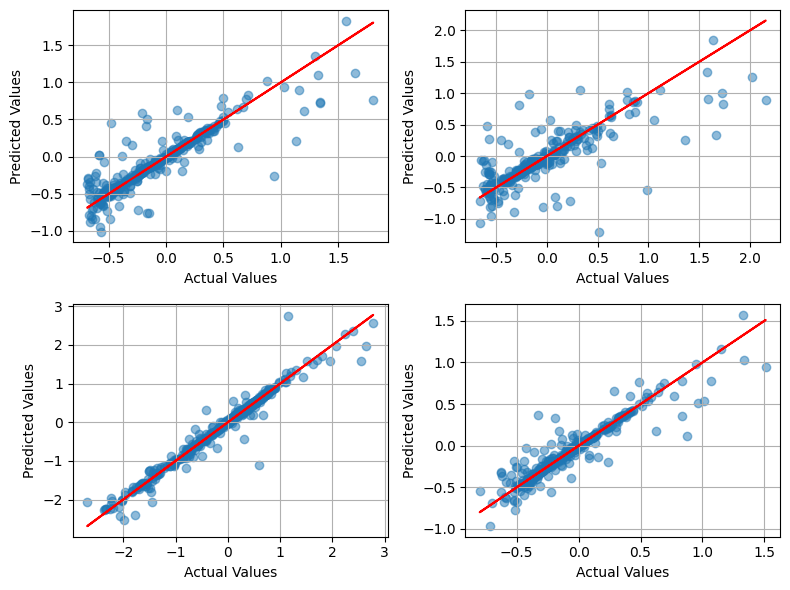

In [6]:
df_y_test_ppred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_ppred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

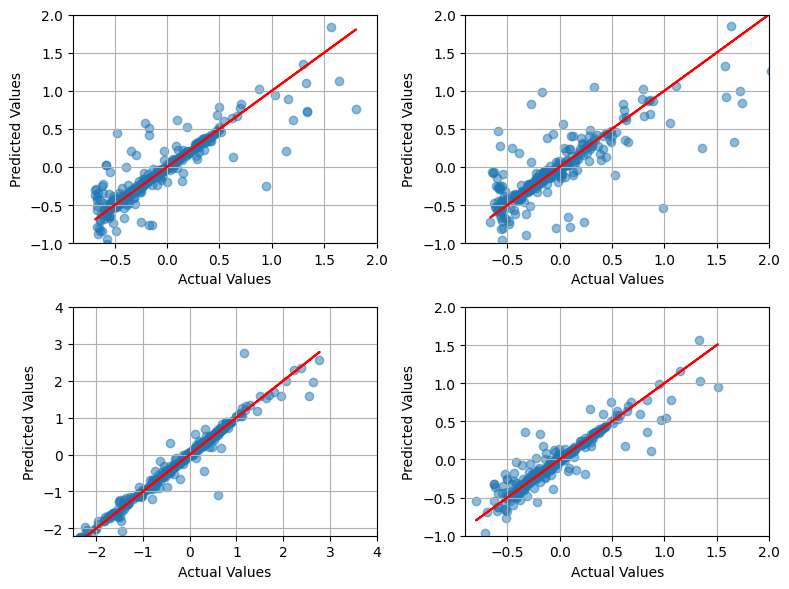

In [7]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_ppred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

(496, 4)


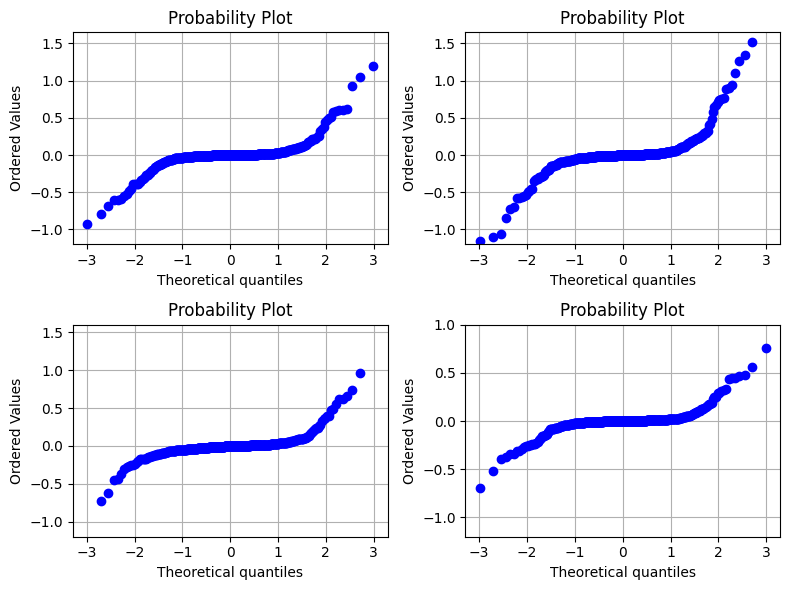

In [8]:
# Normal probability plot
y_test_error=y_test-y_test_pred
print(y_test_error.shape)

fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.2, 1.)
    else: ax.set_ylim(-1.2, 1.65)
    ax.grid(True)
plt.tight_layout()
plt.show()